#  Emotion Detection — Étape 3 : Modèle CNN
**Pipeline :** Chargement données → Dataset/DataLoader → Architecture CNN → Entraînement → Évaluation

---
##  Cellule 1 — Imports & Device

In [34]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device : {device}')
if torch.cuda.is_available():
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

EMOTIONS  = ['angry','calm','disgust','fearful','happy','neutral','sad','surprised']
NUM_CLASS = len(EMOTIONS)
OUT       = '/kaggle/working'

#  Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f' Seed fixée à {SEED}')

 Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB
 Seed fixée à 42


---
##  Cellule 2 — Chargement & Normalisation

In [36]:

X_train = np.load(os.path.join(OUT, 'X_train.npy'))
y_train = np.load(os.path.join(OUT, 'y_train.npy'))
X_val   = np.load(os.path.join(OUT, 'X_val.npy'))
y_val   = np.load(os.path.join(OUT, 'y_val.npy'))
X_test  = np.load(os.path.join(OUT, 'X_test.npy'))
y_test  = np.load(os.path.join(OUT, 'y_test.npy'))

print('Shapes avant normalisation :')
print(f'  X_train : {X_train.shape} | y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}   | y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}  | y_test  : {y_test.shape}')


mean = X_train.mean()
std  = X_train.std()
X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val   - mean) / (std + 1e-8)   # même stats que train
X_test  = (X_test  - mean) / (std + 1e-8)   # même stats que train


X_train = X_train[:, np.newaxis, :, :]
X_val   = X_val[:,   np.newaxis, :, :]
X_test  = X_test[:,  np.newaxis, :, :]

print(f'\nAprès normalisation & reshape :')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  mean={mean:.3f} | std={std:.3f}')

Shapes avant normalisation :
  X_train : (3840, 128, 126) | y_train : (3840,)
  X_val   : (240, 128, 126)   | y_val   : (240,)
  X_test  : (240, 128, 126)  | y_test  : (240,)

Après normalisation & reshape :
  X_train : (3840, 1, 128, 126)
  X_val   : (240, 1, 128, 126)
  X_test  : (240, 1, 128, 126)
  mean=-61.677 | std=18.827


---
##  Cellule 3 — Dataset & DataLoaders

In [37]:
class SERDataset(Dataset):
    """Dataset pour la Speech Emotion Recognition."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_dataset = SERDataset(X_train, y_train)
val_dataset   = SERDataset(X_val,   y_val)
test_dataset  = SERDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f' DataLoaders prêts')
print(f'   Train : {len(train_dataset)} samples ({len(train_loader)} batches)')
print(f'   Val   : {len(val_dataset)} samples   ({len(val_loader)} batches)')
print(f'   Test  : {len(test_dataset)} samples   ({len(test_loader)} batches)')

# Vérification d'un batch
xb, yb = next(iter(train_loader))
print(f'\nBatch shape → X: {xb.shape} | y: {yb.shape}')

 DataLoaders prêts
   Train : 3840 samples (120 batches)
   Val   : 240 samples   (8 batches)
   Test  : 240 samples   (8 batches)

Batch shape → X: torch.Size([32, 1, 128, 126]) | y: torch.Size([32])


---
##  Cellule 4 — Architecture CNN

In [38]:
class EmotionCNN(nn.Module):
    """
    CNN 4 blocs pour la détection d'émotions sur mel-spectrogramme.
    Input  : (B, 1, 128, T)
    Output : (B, num_classes)
    """
    def __init__(self, num_classes=8):
        super().__init__()

        def conv_block(in_ch, out_ch, dropout=0.25):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(dropout),
            )

        self.features = nn.Sequential(
            conv_block(1,   32,  dropout=0.20),   # (1,128,T) → (32,64,T/2)
            conv_block(32,  64,  dropout=0.25),   # → (64,32,T/4)
            conv_block(64,  128, dropout=0.25),   # → (128,16,T/8)
            conv_block(128, 256, dropout=0.30),   # → (256,8,T/16)
            nn.AdaptiveAvgPool2d((1, 1)),          # → (256,1,1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = EmotionCNN(num_classes=NUM_CLASS).to(device)

# Test de la forme
with torch.no_grad():
    dummy = torch.zeros(1, 1, 128, X_train.shape[-1]).to(device)
    out   = model(dummy)
print(f' Modèle OK — input: {dummy.shape} → output: {out.shape}')

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'   Paramètres totaux     : {total:,}')
print(f'   Paramètres entraîn.   : {trainable:,}')

 Modèle OK — input: torch.Size([1, 1, 128, 126]) → output: torch.Size([1, 8])
   Paramètres totaux     : 1,272,360
   Paramètres entraîn.   : 1,272,360


---
##  Cellule 5 — Configuration de l'entraînement

In [39]:
EPOCHS   = 50
LR       = 1e-3
PATIENCE = 10

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

print(f' Critère  : CrossEntropyLoss (label_smoothing=0.1)')
print(f'   Optim    : AdamW (lr={LR}, weight_decay=1e-4)')
print(f'   Scheduler: CosineAnnealingLR (T_max={EPOCHS})')
print(f'   Epochs   : {EPOCHS} | Patience : {PATIENCE}')

 Critère  : CrossEntropyLoss (label_smoothing=0.1)
   Optim    : AdamW (lr=0.001, weight_decay=1e-4)
   Scheduler: CosineAnnealingLR (T_max=50)
   Epochs   : 50 | Patience : 10


---
##  Cellule 6 — Boucle d'entraînement

In [40]:
history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = os.path.join(OUT, 'best_model.pt')

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──────────────────────────────────────────
    model.train()
    train_loss, train_correct = 0.0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
        optimizer.step()
        train_loss    += loss.item() * len(y_batch)
        train_correct += (out.argmax(1) == y_batch).sum().item()

    # ── VALIDATION ─────────────────────────────────────
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            val_loss    += loss.item() * len(y_batch)
            val_correct += (out.argmax(1) == y_batch).sum().item()

    # ── Métriques ──────────────────────────────────────
    tl = train_loss    / len(train_dataset)
    ta = train_correct / len(train_dataset)
    vl = val_loss      / len(val_dataset)
    va = val_correct   / len(val_dataset)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)

    scheduler.step()

    # ── Early stopping ─────────────────────────────────
    if vl < best_val_loss:
        best_val_loss    = vl
        patience_counter = 0
        torch.save({
            'epoch'     : epoch,
            'model_state': model.state_dict(),
            'optimizer' : optimizer.state_dict(),
            'val_loss'  : vl,
            'val_acc'   : va,
        }, best_model_path)
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:02d}/{EPOCHS} | '
              f'Train {tl:.4f} / {ta:.2%} | '
              f'Val {vl:.4f} / {va:.2%} | '
              f'LR {lr_now:.2e} | '
              f'Patience {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\n  Early stopping à l\'epoch {epoch}')
        break

print(f'\n Entraînement terminé — meilleur val_loss : {best_val_loss:.4f}')

Epoch 01/50 | Train 2.0436 / 17.76% | Val 1.9431 / 25.00% | LR 9.99e-04 | Patience 0/10
Epoch 05/50 | Train 1.7625 / 34.45% | Val 1.7654 / 31.25% | LR 9.76e-04 | Patience 1/10
Epoch 10/50 | Train 1.6694 / 40.23% | Val 1.7815 / 38.33% | LR 9.05e-04 | Patience 1/10
Epoch 15/50 | Train 1.5565 / 47.92% | Val 1.7159 / 40.83% | LR 7.94e-04 | Patience 1/10
Epoch 20/50 | Train 1.4138 / 56.07% | Val 1.5665 / 45.83% | LR 6.55e-04 | Patience 0/10
Epoch 25/50 | Train 1.2857 / 62.21% | Val 1.4604 / 52.92% | LR 5.00e-04 | Patience 0/10
Epoch 30/50 | Train 1.1871 / 67.01% | Val 1.4650 / 52.08% | LR 3.46e-04 | Patience 1/10
Epoch 35/50 | Train 1.1160 / 71.22% | Val 1.4390 / 52.50% | LR 2.07e-04 | Patience 4/10
Epoch 40/50 | Train 1.0479 / 75.68% | Val 1.4042 / 53.75% | LR 9.64e-05 | Patience 9/10

  Early stopping à l'epoch 41

 Entraînement terminé — meilleur val_loss : 1.3886


---
##  Cellule 7 — Courbes d'apprentissage

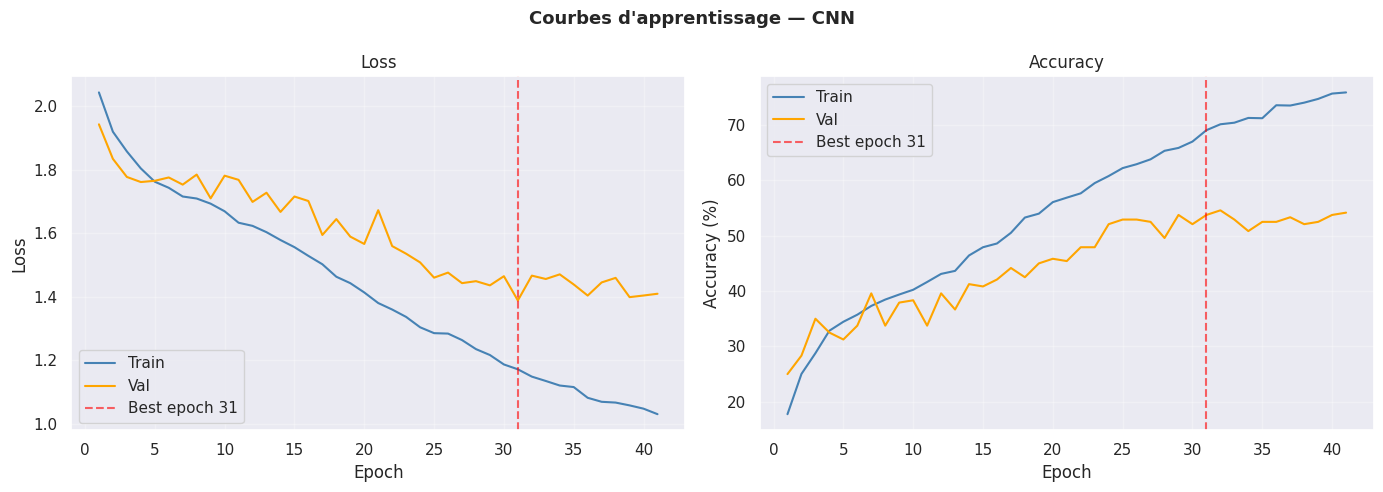

 Sauvegardé | Best epoch : 31 | Best val acc : 54.58%


In [41]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'apprentissage — CNN', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='orange')
best_ep = np.argmin(history['val_loss']) + 1
axes[0].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best epoch {best_ep}')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val',   color='orange')
axes[1].axvline(best_ep, color='red', linestyle='--', alpha=0.6, label=f'Best epoch {best_ep}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'courbes_apprentissage.png'), bbox_inches='tight')
plt.show()
print(f' Sauvegardé | Best epoch : {best_ep} | Best val acc : {max(history["val_acc"]):.2%}')

---
##  Cellule 8 — Évaluation sur le Test set

In [42]:
# Charger le meilleur modèle
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f' Meilleur modèle chargé (epoch {checkpoint["epoch"]} | val_acc {checkpoint["val_acc"]:.2%})')

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

test_acc = (all_preds == all_true).mean()
print(f'\n=== Résultats Test Set ===')
print(f'Accuracy globale : {test_acc:.2%}')
print()
print(classification_report(all_true, all_preds, target_names=EMOTIONS, digits=3))

 Meilleur modèle chargé (epoch 31 | val_acc 53.75%)

=== Résultats Test Set ===
Accuracy globale : 52.50%

              precision    recall  f1-score   support

       angry      0.783     0.562     0.655        32
        calm      0.435     0.938     0.594        32
     disgust      0.491     0.844     0.621        32
     fearful      0.733     0.344     0.468        32
       happy      0.350     0.219     0.269        32
     neutral      0.500     0.062     0.111        16
         sad      0.083     0.031     0.045        32
   surprised      0.705     0.969     0.816        32

    accuracy                          0.525       240
   macro avg      0.510     0.496     0.447       240
weighted avg      0.511     0.525     0.470       240



---
##  Cellule 9 — Matrice de confusion + UAR

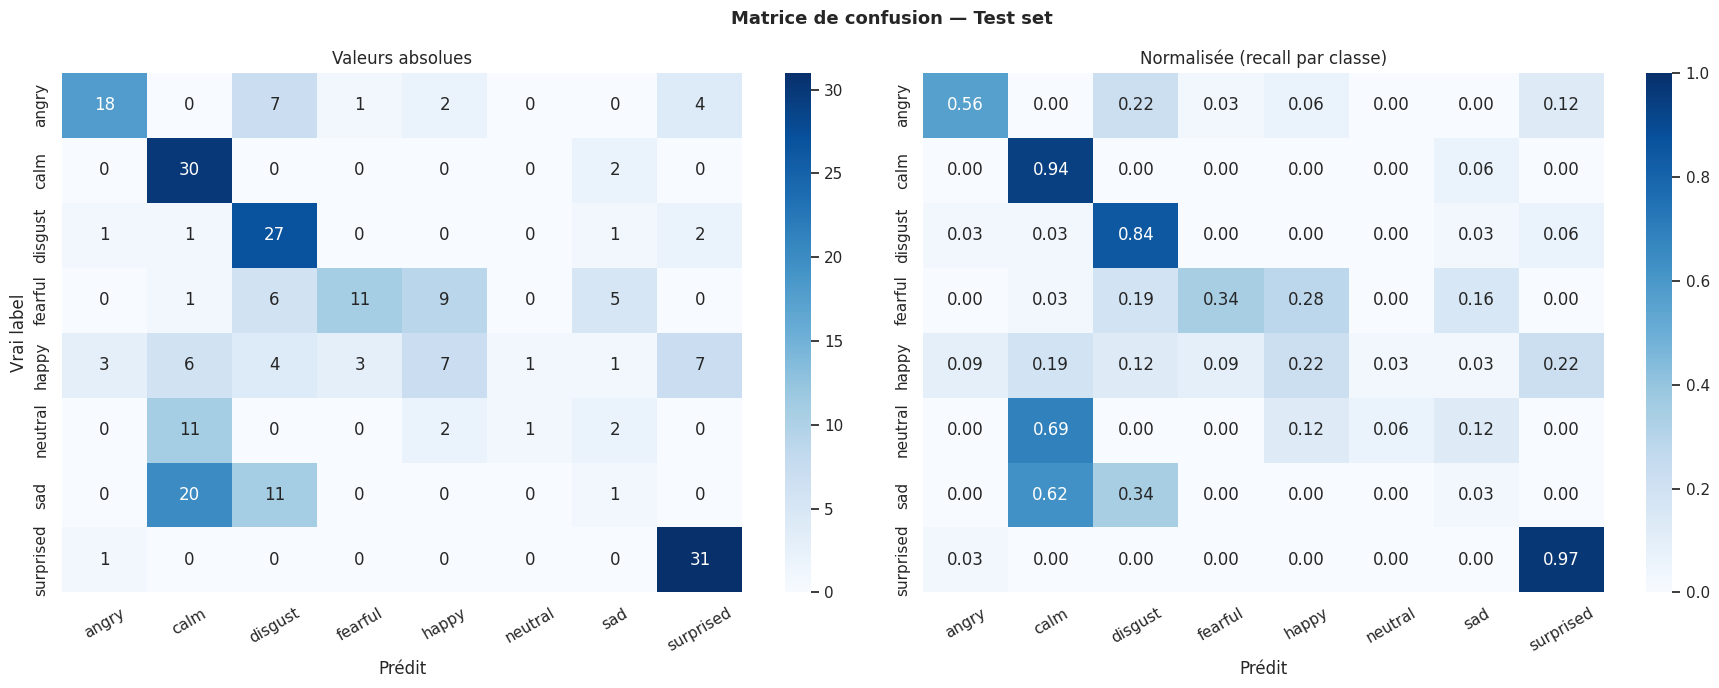


 UAR (Unweighted Average Recall) : 49.61%
 Accuracy globale                : 52.50%

  angry        56.25%  ███████████
  calm         93.75%  ██████████████████
  disgust      84.38%  ████████████████
  fearful      34.38%  ██████
  happy        21.88%  ████
  neutral      6.25%  █
  sad          3.12%  
  surprised    96.88%  ███████████████████


In [43]:
cm = confusion_matrix(all_true, all_preds)

# Matrice normalisée (% par ligne)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrice de confusion — Test set', fontsize=13, fontweight='bold')

# Brute
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Valeurs absolues')
axes[0].set_ylabel('Vrai label')
axes[0].set_xlabel('Prédit')
axes[0].tick_params(axis='x', rotation=30)

# Normalisée
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalisée (recall par classe)')
axes[1].set_ylabel('')
axes[1].set_xlabel('Prédit')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'confusion_matrix.png'), bbox_inches='tight')
plt.show()

# UAR — métrique standard SER
recalls = cm.diagonal() / cm.sum(axis=1)
uar     = recalls.mean()
print(f'\n UAR (Unweighted Average Recall) : {uar:.2%}')
print(f' Accuracy globale                : {test_acc:.2%}')
print()
for emo, rec in zip(EMOTIONS, recalls):
    bar = '█' * int(rec * 20)
    print(f'  {emo:<12} {rec:.2%}  {bar}')

---
##  Cellule 10 — Résumé final

In [44]:
print('=' * 55)
print('        RÉSUMÉ — MODÈLE CNN')
print('=' * 55)
print(f'  Architecture    : EmotionCNN (4 blocs conv)')
print(f'  Paramètres      : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Epochs réels    : {len(history["train_loss"])}/{EPOCHS}')
print(f'  Best epoch      : {np.argmin(history["val_loss"]) + 1}')
print(f'  Val accuracy    : {max(history["val_acc"]):.2%}')
print(f'  Test accuracy   : {test_acc:.2%}')
print(f'  UAR             : {uar:.2%}')
print('=' * 55)


        RÉSUMÉ — MODÈLE CNN
  Architecture    : EmotionCNN (4 blocs conv)
  Paramètres      : 1,272,360
  Epochs réels    : 41/50
  Best epoch      : 31
  Val accuracy    : 54.58%
  Test accuracy   : 52.50%
  UAR             : 49.61%
